# DAY 1. ESS 배터리 EDA 및 모델 전략 수립

## 목적

초기 10·100사이클 데이터에서 배터리 수명과 관련된 신호를 찾고, 통계적 근거와 배터리 도메인 근거를 결합해 피처와 후보 모델을 선정합니다.

## 분석 원칙

- Batch 1에서만 타깃 기반 피처 선택과 모델 전략 수립을 수행합니다.
- Batch 2는 DAY 2 최종 평가용으로 보존합니다.
- 모든 결과를 `그래프 → 핵심 발견 → 해석 → 모델링 시사점` 순서로 정리합니다.
- 미래의 knee point와 EOL 이후 정보는 예측 피처로 사용하지 않습니다.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import KFold, cross_val_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (9, 5)

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data').exists() and (PROJECT_ROOT.parent / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURE_DIR = PROJECT_ROOT / 'results' / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(PROCESSED_DIR / 'batch1_features.parquet')
df['life_group'] = pd.cut(
    df['cycle_life'], bins=[-np.inf, 500, 1000, np.inf],
    labels=['Short (<500)', 'Middle (500-1000)', 'Long (>1000)']
)
df['label_550'] = (df['cycle_life'] >= 550).astype(int)
print('Batch 1:', df.shape)
display(df.head())

Batch 1: (46, 56)


,batch,cell_id,barcode,charging_policy,cycle_life,cycle_10_actual,cycle_100_actual,c_rate_1,switch_soc,c_rate_2,...,dQ_std,dQ_var,dQ_log_var,dQ_min,dQ_max,dQ_abs_area,dQ_area,dQ_min_voltage,life_group,label_550
0,batch1,batch1_cell_00,,3.6C(80%)-3.6C,1190.0,10.0,100.0,3.6,80.0,3.6,...,0.003110,0.000010,-5.014427,-0.008460,0.000768,0.004437,-0.004315,3.064565,Long (>1000),1
1,batch1,batch1_cell_01,,3.6C(80%)-3.6C,1179.0,10.0,100.0,3.6,80.0,3.6,...,0.003113,0.000010,-5.013525,-0.011004,-0.000088,0.006155,-0.006155,3.136637,Long (>1000),1
2,batch1,batch1_cell_02,,3.6C(80%)-3.6C,1177.0,10.0,100.0,3.6,80.0,3.6,...,0.004283,0.000018,-4.736565,-0.017216,0.000013,0.006737,-0.006736,3.153153,Long (>1000),1
3,batch1,batch1_cell_03,,4C(80%)-4C,1226.0,10.0,100.0,4.0,80.0,4.0,...,0.006010,0.000036,-4.442179,-0.018961,0.000182,0.011212,-0.011194,2.957958,Long (>1000),1
4,batch1,batch1_cell_04,,4C(80%)-4C,1227.0,10.0,100.0,4.0,80.0,4.0,...,0.004746,0.000023,-4.647309,-0.013958,0.000046,0.008635,-0.008633,2.878378,Long (>1000),1


## 데이터 품질 및 분석 대상

In [2]:
quality = pd.DataFrame({
    'missing_n': df.isna().sum(),
    'missing_rate': df.isna().mean(),
    'unique_n': df.nunique(dropna=True),
}).sort_values('missing_rate', ascending=False)
display(quality.head(20))

print('cells:', len(df))
print('cycle 100 usable:', (df['cycle_100_actual'] >= 95).sum())

,missing_n,missing_rate,unique_n
batch,0,0.0,1
cell_id,0,0.0,46
Tmin_10,0,0.0,46
Tmin_100,0,0.0,46
Tmin_diff,0,0.0,46
Tmin_slope,0,0.0,46
Tmin_ratio,0,0.0,46
Tmax_10,0,0.0,46
Tmax_100,0,0.0,46
Tmax_diff,0,0.0,46


cells: 46
cycle 100 usable: 46


## Q1. Cycle Life 분포는 어떻게 생겼는가?

**가설:** Cycle Life는 정규분포보다 우측으로 치우치며, 로그 변환이 회귀에 더 적합할 수 있다.

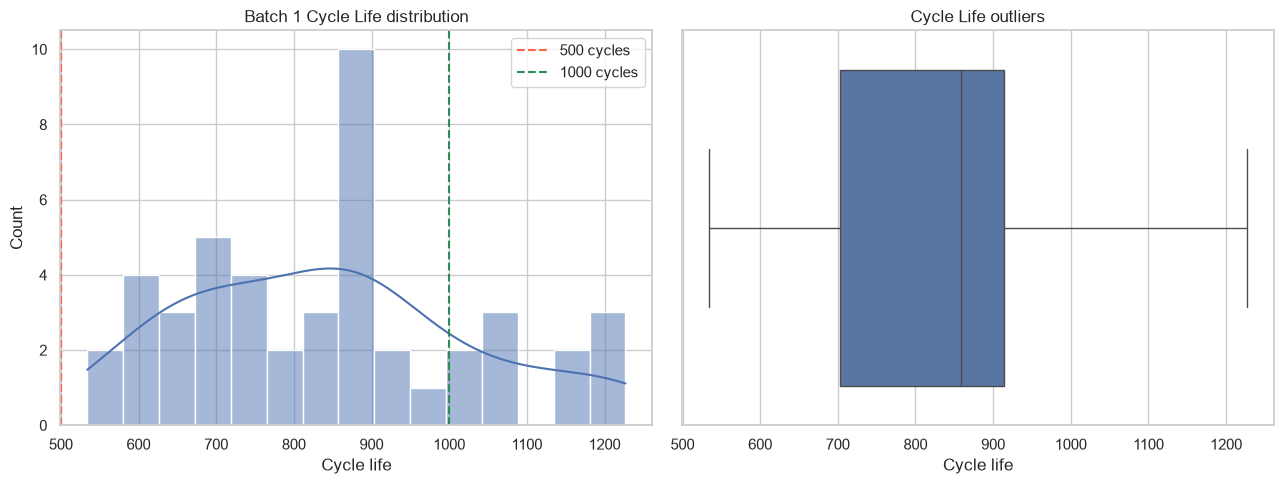

,value
count,46.000000
mean,844.717391
std,184.629198
min,534.000000
25%,703.250000
50%,858.500000
75%,914.250000
max,1227.000000
skew,0.452864
short_<500,0.000000


Raw Shapiro p=0.0641
Log Shapiro p=0.3015


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df['cycle_life'], bins=15, kde=True, ax=axes[0])
axes[0].axvline(500, color='tomato', ls='--', label='500 cycles')
axes[0].axvline(1000, color='seagreen', ls='--', label='1000 cycles')
axes[0].set(title='Batch 1 Cycle Life distribution', xlabel='Cycle life')
axes[0].legend()
sns.boxplot(x=df['cycle_life'], ax=axes[1])
axes[1].set(title='Cycle Life outliers', xlabel='Cycle life')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'q1_cycle_life_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

life_summary = df['cycle_life'].describe().to_frame('value')
life_summary.loc['skew'] = df['cycle_life'].skew()
life_summary.loc['short_<500'] = (df['cycle_life'] < 500).mean()
life_summary.loc['long_>1000'] = (df['cycle_life'] > 1000).mean()
display(life_summary)

shapiro = stats.shapiro(df['cycle_life'])
log_shapiro = stats.shapiro(np.log1p(df['cycle_life']))
print(f'Raw Shapiro p={shapiro.pvalue:.4g}')
print(f'Log Shapiro p={log_shapiro.pvalue:.4g}')

### 해석 및 모델링 시사점

- 히스토그램의 치우침, 왜도, 정규성 검정 결과를 함께 보고 원본 타깃과 `log1p(cycle_life)`를 비교합니다.
- 극단 수명 셀을 임의로 제거하지 않고 영향점 분석과 강건성 검토 대상으로 남깁니다.
- 550사이클 기준 클래스 비율이 심하게 불균형하면 분류 모델에 stratification과 class weight를 적용합니다.

## Q2. 초기 방전 용량 열화는 수명과 관련이 있는가?

**가설:** 10→100사이클의 방전 용량 감소율이 클수록 Cycle Life가 짧다.

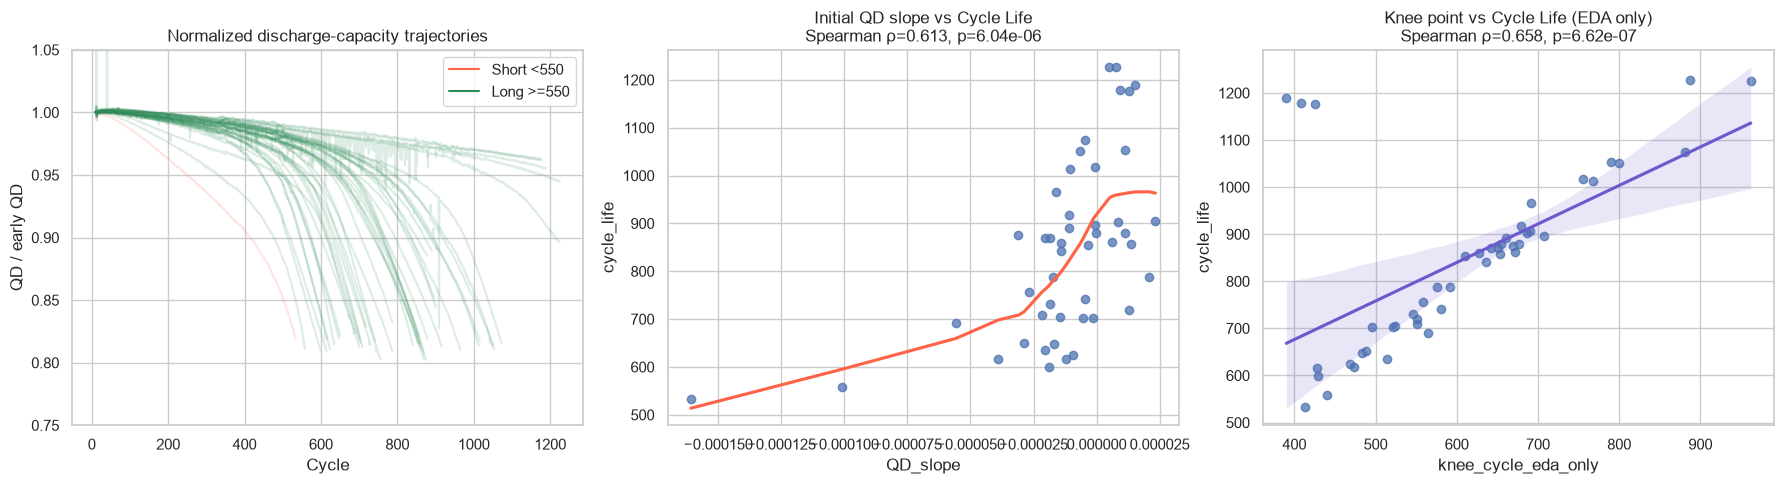

QD slope group difference: Mann-Whitney U p=0.04348
주의: knee point는 수명 후반 정보이므로 모델 피처로 사용하지 않습니다.


In [4]:
degradation = np.load(PROCESSED_DIR / 'batch1_degradation_curves.npz', allow_pickle=True)
cycle_curves, qd_curves = degradation['cycle'], degradation['qd']

def piecewise_knee(cycles, capacity, min_fraction=.15, max_fraction=.90):
    mask = np.isfinite(cycles) & np.isfinite(capacity)
    x, y = np.asarray(cycles)[mask], np.asarray(capacity)[mask]
    if len(x) < 30:
        return np.nan
    y = pd.Series(y).rolling(9, center=True, min_periods=1).median().to_numpy()
    lo, hi = max(5, int(len(x) * min_fraction)), min(len(x) - 5, int(len(x) * max_fraction))
    candidates = range(lo, hi)
    losses = []
    for split in candidates:
        left = np.polyfit(x[:split], y[:split], 1)
        right = np.polyfit(x[split:], y[split:], 1)
        loss = np.square(y[:split] - np.polyval(left, x[:split])).sum()
        loss += np.square(y[split:] - np.polyval(right, x[split:])).sum()
        losses.append(loss)
    return float(x[list(candidates)[int(np.argmin(losses))]])

knees = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {0: 'tomato', 1: 'seagreen'}
for i, (cycles, qd) in enumerate(zip(cycle_curves, qd_curves)):
    cycles, qd = np.asarray(cycles, float), np.asarray(qd, float)
    ref = np.nanmedian(qd[(cycles >= 5) & (cycles <= 15)])
    normalized = qd / ref if np.isfinite(ref) and ref != 0 else qd
    label = int(df.loc[i, 'label_550'])
    plot_mask = cycles >= 10
    axes[0].plot(cycles[plot_mask], normalized[plot_mask], color=colors[label], alpha=.16)
    knees.append(piecewise_knee(cycles, normalized))
axes[0].plot([], [], color='tomato', label='Short <550')
axes[0].plot([], [], color='seagreen', label='Long >=550')
axes[0].set(title='Normalized discharge-capacity trajectories', xlabel='Cycle', ylabel='QD / early QD')
axes[0].set_ylim(.75, 1.05)
axes[0].legend()

df['knee_cycle_eda_only'] = knees
valid = df[['QD_slope', 'cycle_life', 'label_550', 'knee_cycle_eda_only']].dropna()
rho, pvalue = stats.spearmanr(valid['QD_slope'], valid['cycle_life'])
sns.regplot(data=valid, x='QD_slope', y='cycle_life', lowess=True,
            scatter_kws={'alpha': .75}, line_kws={'color': 'tomato'}, ax=axes[1])
axes[1].set_title(f'Initial QD slope vs Cycle Life\nSpearman ρ={rho:.3f}, p={pvalue:.3g}')

knee_rho, knee_p = stats.spearmanr(valid['knee_cycle_eda_only'], valid['cycle_life'])
sns.regplot(data=valid, x='knee_cycle_eda_only', y='cycle_life', ax=axes[2],
            scatter_kws={'alpha': .75}, line_kws={'color': 'slateblue'})
axes[2].set_title(f'Knee point vs Cycle Life (EDA only)\nSpearman ρ={knee_rho:.3f}, p={knee_p:.3g}')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'q2_qd_degradation.png', dpi=160, bbox_inches='tight')
plt.show()

g0 = valid.loc[valid['label_550'] == 0, 'QD_slope']
g1 = valid.loc[valid['label_550'] == 1, 'QD_slope']
u = stats.mannwhitneyu(g0, g1, alternative='two-sided')
print(f'QD slope group difference: Mann-Whitney U p={u.pvalue:.4g}')
print('주의: knee point는 수명 후반 정보이므로 모델 피처로 사용하지 않습니다.')

### 해석 및 모델링 시사점

- 상관 방향, 효과 크기, 그룹 차이를 함께 확인해 `QD_diff`, `QD_slope`, `QD_ratio` 중 대표 피처를 선택합니다.
- 세 피처는 같은 정보를 공유할 가능성이 크므로 동시에 채택하지 않고 VIF와 교차검증으로 중복을 줄입니다.
- LOWESS가 직선과 다른 형태라면 선형 모델뿐 아니라 SVR·Boosting 계열도 후보로 둡니다.

## Q3. ΔQ(V)는 초기 사이클에서 수명 차이를 보여주는가?

**가설:** 10→100사이클 ΔQ(V)의 변동이 큰 셀일수록 수명이 짧다.

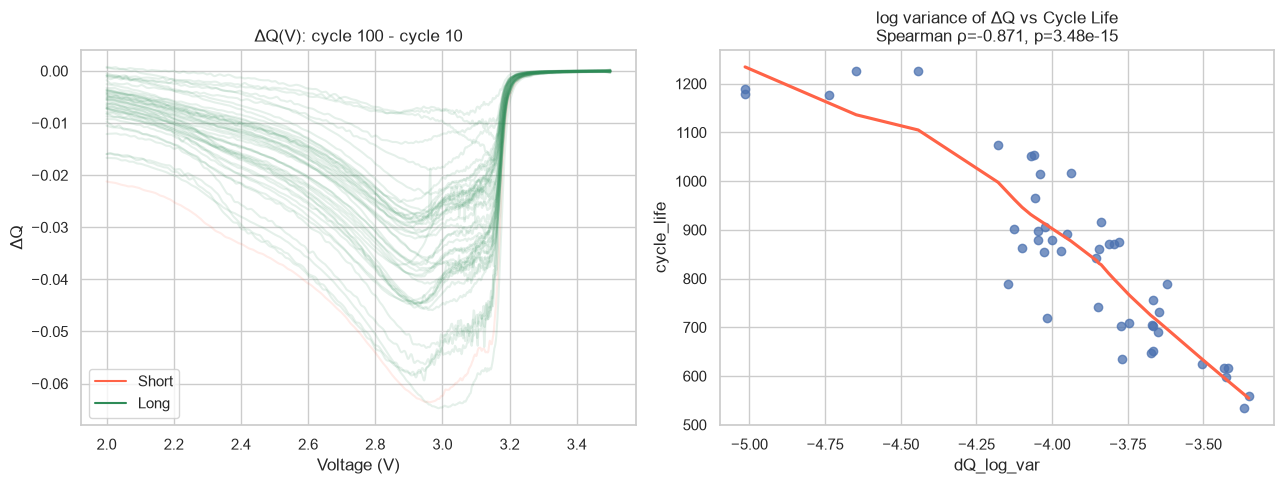

In [5]:
dq_data = np.load(PROCESSED_DIR / 'batch1_dq_curves.npz', allow_pickle=True)
dq_curves = dq_data['dq']
voltage_axes = dq_data['voltage']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for label, color, name in [(0, 'tomato', 'Short'), (1, 'seagreen', 'Long')]:
    indices = df.index[df['label_550'] == label]
    for i in indices:
        axes[0].plot(voltage_axes[i], dq_curves[i], color=color, alpha=.12)
    axes[0].plot([], [], color=color, label=name)
axes[0].set(title='ΔQ(V): cycle 100 - cycle 10', xlabel='Voltage (V)', ylabel='ΔQ')
axes[0].legend()

valid = df[['dQ_log_var', 'cycle_life', 'label_550']].dropna()
rho, pvalue = stats.spearmanr(valid['dQ_log_var'], valid['cycle_life'])
sns.regplot(data=valid, x='dQ_log_var', y='cycle_life', lowess=True,
            scatter_kws={'alpha': .75}, line_kws={'color': 'tomato'}, ax=axes[1])
axes[1].set_title(f'log variance of ΔQ vs Cycle Life\nSpearman ρ={rho:.3f}, p={pvalue:.3g}')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'q3_delta_q.png', dpi=160, bbox_inches='tight')
plt.show()

### 해석 및 모델링 시사점

- 원본 곡선 1,000포인트를 직접 투입하지 않고 분산, 최솟값, 면적 등 저차원 통계량으로 압축합니다.
- 장·단수명 곡선의 겹침 정도와 `dQ_log_var`의 상관관계를 보고 ΔQ 피처의 실효성을 판단합니다.
- ΔQ 파생변수끼리 높은 상관이 예상되므로 대표 피처만 유지합니다.

## Q4. 충전 조건과 수명은 관련이 있는가?

**가설:** 높은 초기 C-rate는 Cycle Life 감소와 관련이 있다.

,n,mean,median,std
charging_policy,,,,
5.4C(80%)-5.4C,2,546.5,546.5,17.677670
8C(35%)-3.6C,2,607.5,607.5,12.020815
7C(40%)-3.6C,2,621.0,621.0,5.656854
7C(40%)-3C,2,676.0,676.0,39.597980
8C(25%)-3.6C,2,676.5,676.5,36.062446
7C(30%)-3.6C,2,722.5,722.5,27.577164
5.4C(70%)-3C,2,739.5,739.5,68.589358
6C(60%)-3C,2,744.0,744.0,18.384776
4.8C(80%)-4.8C,2,753.0,753.0,165.462987


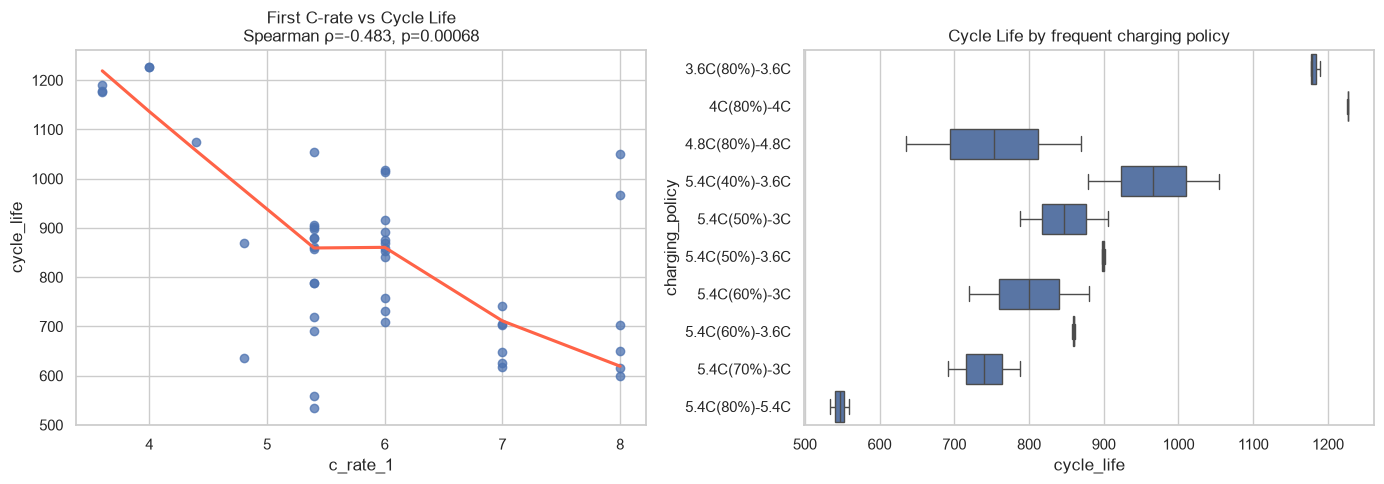

Kruskal-Wallis p=0.009983


In [6]:
valid = df[['c_rate_1', 'cycle_life', 'charging_policy']].dropna()
rho, pvalue = stats.spearmanr(valid['c_rate_1'], valid['cycle_life'])

policy_summary = (df.groupby('charging_policy', dropna=False)['cycle_life']
                  .agg(n='size', mean='mean', median='median', std='std')
                  .sort_values('median'))
display(policy_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.regplot(data=valid, x='c_rate_1', y='cycle_life', lowess=True,
            scatter_kws={'alpha': .75}, line_kws={'color': 'tomato'}, ax=axes[0])
axes[0].set_title(f'First C-rate vs Cycle Life\nSpearman ρ={rho:.3f}, p={pvalue:.3g}')

top_policies = df['charging_policy'].value_counts().head(10).index
plot_df = df[df['charging_policy'].isin(top_policies)]
sns.boxplot(data=plot_df, y='charging_policy', x='cycle_life', ax=axes[1])
axes[1].set_title('Cycle Life by frequent charging policy')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'q4_charging_policy.png', dpi=160, bbox_inches='tight')
plt.show()

groups = [g['cycle_life'].values for _, g in df.groupby('charging_policy') if len(g) >= 2]
if len(groups) >= 2:
    test = stats.kruskal(*groups)
    print(f'Kruskal-Wallis p={test.pvalue:.4g}')

### 해석 및 모델링 시사점

- 프로토콜별 표본 수와 분산을 함께 보고 작은 그룹의 평균을 과해석하지 않습니다.
- 범주형 프로토콜 자체가 유효하면 이를 직접 처리하는 CatBoost를 후보에 포함합니다.
- C-rate 숫자 분해만으로 정보가 충분하면 범주형 문자열을 제거하고 다른 정형 모델과 공정하게 비교합니다.
- 관찰 연구이므로 관련성을 인과관계로 표현하지 않습니다.

## Q5. 어떤 초기 신호가 수명과 연관되어 있는가?

단변량 상관, 다중검정 보정, OLS, VIF를 함께 사용합니다.

,feature,n,pearson_r,pearson_p,spearman_rho,spearman_p,spearman_p_fdr
40,dQ_var,46,-0.837826,3.845425e-13,-0.871161,3.484999e-15,5.575998e-14
41,dQ_log_var,46,-0.886123,2.702899e-16,-0.871161,3.484999e-15,5.575998e-14
39,dQ_std,46,-0.893713,6.422592e-17,-0.871161,3.484999e-15,5.575998e-14
42,dQ_min,46,0.881645,6.021711e-16,0.850006,7.873942e-14,9.448731e-13
45,dQ_area,46,0.853841,4.641608e-14,0.828112,1.244280e-12,8.532203e-12
44,dQ_abs_area,46,-0.853825,4.652012e-14,-0.828112,1.244280e-12,8.532203e-12
38,dQ_mean,46,0.853810,4.662050e-14,0.828112,1.244280e-12,8.532203e-12
47,knee_cycle_eda_only,46,0.599827,1.055114e-05,0.658279,6.621950e-07,3.973170e-06
33,chargetime_10,46,0.738858,4.557512e-09,0.630319,2.673196e-06,1.425705e-05
34,chargetime_100,46,0.734178,6.386648e-09,0.622487,3.856990e-06,1.851355e-05


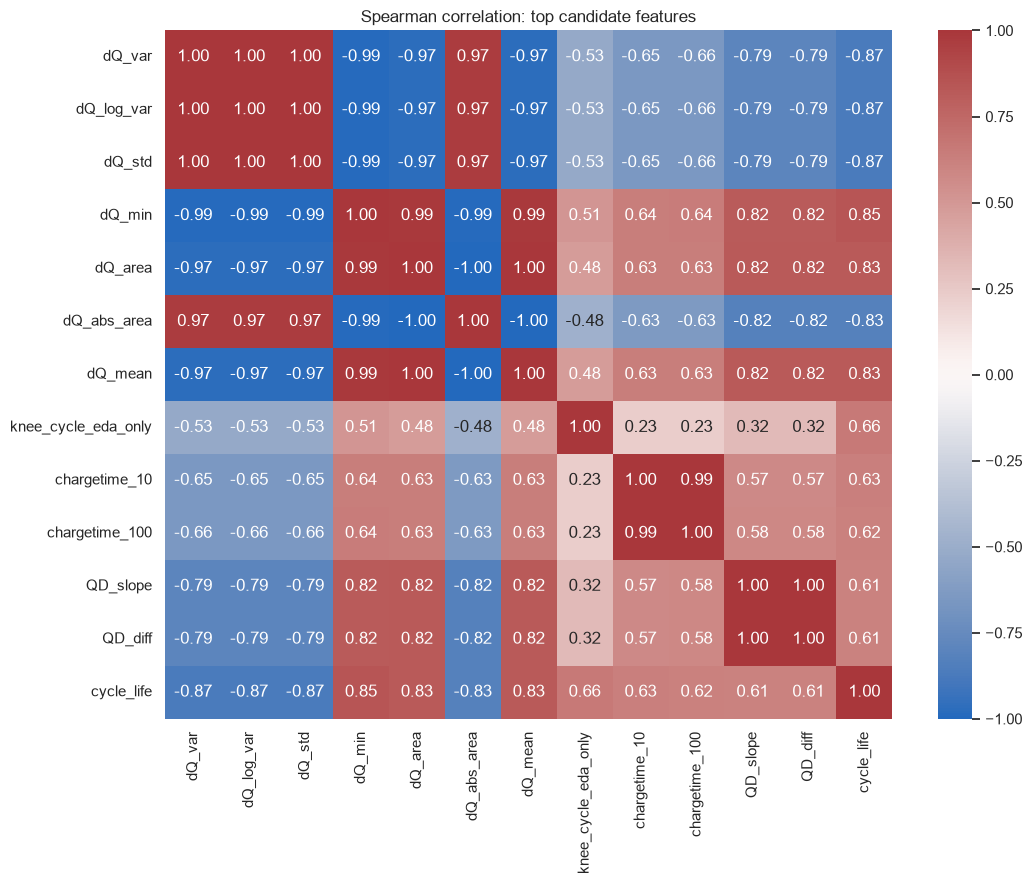

In [7]:
exclude = {
    'cycle_life', 'label_550', 'cycle_10_actual', 'cycle_100_actual'
}
numeric_features = [
    c for c in df.select_dtypes(include=np.number).columns
    if c not in exclude and df[c].nunique(dropna=True) > 2
]

rows = []
for feature in numeric_features:
    sample = df[[feature, 'cycle_life']].dropna()
    if len(sample) < 8:
        continue
    pearson = stats.pearsonr(sample[feature], sample['cycle_life'])
    spearman = stats.spearmanr(sample[feature], sample['cycle_life'])
    rows.append({
        'feature': feature,
        'n': len(sample),
        'pearson_r': pearson.statistic,
        'pearson_p': pearson.pvalue,
        'spearman_rho': spearman.statistic,
        'spearman_p': spearman.pvalue,
    })

univariate = pd.DataFrame(rows)
univariate['spearman_p_fdr'] = multipletests(
    univariate['spearman_p'], method='fdr_bh'
)[1]
univariate = univariate.sort_values('spearman_rho', key=lambda s: s.abs(), ascending=False)
display(univariate.head(20))

top_features = univariate.head(12)['feature'].tolist()
plt.figure(figsize=(11, 9))
sns.heatmap(df[top_features + ['cycle_life']].corr(method='spearman'),
            cmap='vlag', center=0, annot=True, fmt='.2f')
plt.title('Spearman correlation: top candidate features')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'q5_correlation_heatmap.png', dpi=160, bbox_inches='tight')
plt.show()

## OLS 및 다중공선성 진단

상관순위 상위 피처에서 같은 계열의 원본값·차이·비율이 중복되지 않도록 대표 변수를 먼저 고릅니다.

In [8]:
preferred = [
    'dQ_log_var', 'dQ_min', 'dQ_abs_area',
    'QD_slope', 'IR_slope', 'Tavg_10', 'Tmax_10',
    'chargetime_10', 'c_rate_1', 'switch_soc', 'c_rate_2'
]
candidate_features = [c for c in preferred if c in df and df[c].notna().mean() >= .8]

model_df = df[candidate_features + ['cycle_life']].dropna().copy()
X = model_df[candidate_features]
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns, index=X.index)
y = np.log1p(model_df['cycle_life'])

vif = pd.DataFrame({
    'feature': X_scaled.columns,
    'VIF': [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]
}).sort_values('VIF', ascending=False)
display(vif)

ols = sm.OLS(y, sm.add_constant(X_scaled)).fit(cov_type='HC3')
display(pd.DataFrame({
    'coef': ols.params,
    'pvalue_HC3': ols.pvalues,
    'ci_low': ols.conf_int()[0],
    'ci_high': ols.conf_int()[1],
}).sort_values('pvalue_HC3'))
print(ols.summary())

# 같은 ΔQ 정보를 반복하는 피처는 대표값 하나만 유지한 축소 모형도 확인합니다.
reduced_features = [
    c for c in [
        'dQ_log_var', 'QD_slope', 'IR_slope', 'Tmax_10',
        'chargetime_10', 'c_rate_1', 'switch_soc', 'c_rate_2'
    ] if c in model_df
]
X_reduced = model_df[reduced_features]
X_reduced_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_reduced),
    columns=reduced_features,
    index=X_reduced.index,
)
reduced_vif = pd.DataFrame({
    'feature': reduced_features,
    'VIF_reduced': [
        variance_inflation_factor(X_reduced_scaled.values, i)
        for i in range(X_reduced_scaled.shape[1])
    ]
}).sort_values('VIF_reduced', ascending=False)
reduced_ols = sm.OLS(y, sm.add_constant(X_reduced_scaled)).fit(cov_type='HC3')
print('Reduced model: one representative ΔQ feature')
display(reduced_vif)
display(pd.DataFrame({
    'coef': reduced_ols.params,
    'pvalue_HC3': reduced_ols.pvalues,
    'ci_low': reduced_ols.conf_int()[0],
    'ci_high': reduced_ols.conf_int()[1],
}).sort_values('pvalue_HC3'))

,feature,VIF
1,dQ_min,147.900057
2,dQ_abs_area,114.892510
0,dQ_log_var,39.677821
5,Tavg_10,37.365706
6,Tmax_10,28.040362
8,c_rate_1,12.661804
9,switch_soc,9.664766
7,chargetime_10,7.687783
3,QD_slope,5.965349
4,IR_slope,3.598914


,coef,pvalue_HC3,ci_low,ci_high
const,6.717130,0.000000,6.563795,6.870466
dQ_min,0.383922,0.143856,-0.130913,0.898756
dQ_abs_area,0.225941,0.273576,-0.178526,0.630409
switch_soc,-0.042968,0.423407,-0.148169,0.062233
chargetime_10,0.032464,0.437274,-0.049446,0.114375
c_rate_1,-0.061984,0.460669,-0.226657,0.102689
Tmax_10,-0.021390,0.831335,-0.218225,0.175444
dQ_log_var,0.026637,0.853431,-0.255956,0.309230
c_rate_2,0.001965,0.963270,-0.081688,0.085619
IR_slope,0.011545,0.982876,-1.042731,1.065822


                            OLS Regression Results                            
Dep. Variable:             cycle_life   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.791
Method:                 Least Squares   F-statistic:                     23.14
Date:                Thu, 01 Oct 2026   Prob (F-statistic):           1.23e-12
Time:                        15:22:13   Log-Likelihood:                 47.975
No. Observations:                  46   AIC:                            -71.95
Df Residuals:                      34   BIC:                            -50.01
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             6.7171      0.078     85.860

,feature,VIF_reduced
0,dQ_log_var,11.356527
5,c_rate_1,9.711043
6,switch_soc,6.758371
4,chargetime_10,6.083586
1,QD_slope,3.513674
7,c_rate_2,2.461945
2,IR_slope,1.378230
3,Tmax_10,1.161432


,coef,pvalue_HC3,ci_low,ci_high
const,6.717130,0.000000,6.661223,6.773037
switch_soc,-0.098542,0.008857,-0.172330,-0.024755
dQ_log_var,-0.147299,0.028446,-0.279061,-0.015537
Tmax_10,-0.029566,0.047801,-0.058846,-0.000286
c_rate_1,-0.097316,0.089652,-0.209697,0.015064
c_rate_2,-0.006135,0.847608,-0.068701,0.056432
chargetime_10,-0.006600,0.852622,-0.076232,0.063032
QD_slope,0.006816,0.886964,-0.087167,0.100799
IR_slope,0.005150,0.973659,-0.300561,0.310862


## 교차검증 기반 선택 안정성

OLS는 설명 근거로 사용하고, Elastic Net의 반복 교차검증으로 예측 기여가 유지되는지도 확인합니다.

In [9]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
elastic = ElasticNetCV(
    l1_ratio=[.1, .5, .9, 1.0],
    alphas=np.logspace(-4, 1, 100),
    cv=cv,
    max_iter=50_000,
).fit(X_scaled, y)

elastic_result = pd.DataFrame({
    'feature': X_scaled.columns,
    'elastic_coef': elastic.coef_,
    'selected': elastic.coef_ != 0,
}).sort_values('elastic_coef', key=lambda s: s.abs(), ascending=False)
display(elastic_result)
print('selected alpha:', elastic.alpha_)
print('selected l1_ratio:', elastic.l1_ratio_)

,feature,elastic_coef,selected
1,dQ_min,0.143942,True
0,dQ_log_var,-0.023236,True
6,Tmax_10,-0.014138,True
7,chargetime_10,0.009913,True
2,dQ_abs_area,-0.000000,False
3,QD_slope,0.000000,False
4,IR_slope,0.000000,False
5,Tavg_10,-0.000000,False
8,c_rate_1,-0.000000,False
9,switch_soc,-0.000000,False


selected alpha: 0.016681005372000592
selected l1_ratio: 0.9


## 최종 피처 선정 근거표

In [10]:
domain_reason = {
    'dQ_log_var': '초기 방전 곡선 변화의 크기',
    'dQ_min': 'ΔQ 곡선의 최대 음의 변화',
    'dQ_abs_area': '전압 전 구간의 누적 변화량',
    'QD_slope': '초기 방전 용량 감소 속도',
    'IR_slope': '초기 내부 저항 증가 속도',
    'Tavg_10': '초기 평균 열 스트레스',
    'Tmax_10': '초기 최고 열 스트레스',
    'chargetime_10': '초기 충전 거동',
    'c_rate_1': '초기 급속 충전 강도',
    'switch_soc': '충전 단계 전환 조건',
    'c_rate_2': '후반 충전 강도',
}

selection = pd.DataFrame({'feature': candidate_features})
selection['domain_reason'] = selection['feature'].map(domain_reason)
selection = selection.merge(
    univariate[['feature', 'spearman_rho', 'spearman_p_fdr']], on='feature', how='left'
).merge(vif, on='feature', how='left').merge(
    pd.DataFrame({'feature': ols.params.index, 'ols_p_HC3': ols.pvalues.values}),
    on='feature', how='left'
).merge(elastic_result, on='feature', how='left')

selection['evidence'] = np.select(
    [
        (selection['spearman_p_fdr'] < .05) & (selection['VIF'] < 10) & selection['selected'].fillna(False),
        (selection['spearman_p_fdr'] < .05) & (selection['VIF'] >= 10),
    ],
    ['우선 후보', '다중공선성 검토'],
    default='CV 기여 추가 검토'
)
display(selection.sort_values(['evidence', 'spearman_p_fdr']))
selection.to_csv(PROJECT_ROOT / 'results' / 'feature_selection.csv', index=False)

,feature,domain_reason,spearman_rho,spearman_p_fdr,VIF,ols_p_HC3,elastic_coef,selected,evidence
3,QD_slope,초기 방전 용량 감소 속도,0.612619,2.075230e-05,5.965349,0.990489,0.000000,False,CV 기여 추가 검토
6,Tmax_10,초기 최고 열 스트레스,-0.269829,1.014607e-01,28.040362,0.831335,-0.014138,True,CV 기여 추가 검토
4,IR_slope,초기 내부 저항 증가 속도,-0.240286,1.397480e-01,3.598914,0.982876,0.000000,False,CV 기여 추가 검토
9,switch_soc,충전 단계 전환 조건,0.185159,2.491118e-01,9.664766,0.423407,-0.000000,False,CV 기여 추가 검토
10,c_rate_2,후반 충전 강도,0.047414,7.704024e-01,3.347315,0.963270,0.000000,False,CV 기여 추가 검토
0,dQ_log_var,초기 방전 곡선 변화의 크기,-0.871161,5.575998e-14,39.677821,0.853431,-0.023236,True,다중공선성 검토
1,dQ_min,ΔQ 곡선의 최대 음의 변화,0.850006,9.448731e-13,147.900057,0.143856,0.143942,True,다중공선성 검토
2,dQ_abs_area,전압 전 구간의 누적 변화량,-0.828112,8.532203e-12,114.892510,0.273576,-0.000000,False,다중공선성 검토
8,c_rate_1,초기 급속 충전 강도,-0.482714,1.631592e-03,12.661804,0.460669,-0.000000,False,다중공선성 검토
5,Tavg_10,초기 평균 열 스트레스,-0.346121,3.055578e-02,37.365706,0.996221,-0.000000,False,다중공선성 검토


## EDA에서 모델 전략으로

최종 후보 모델은 이름만 나열하지 않고 확인된 데이터 특성과 연결합니다.

| EDA에서 확인할 특성 | 후보 모델 | 선정 이유 |
|---|---|---|
| 피처 간 다중공선성 | Ridge / Elastic Net | 규제로 계수 불안정을 줄이고 기준 성능을 제공 |
| 연속형 피처와 타깃의 비선형 관계 | RBF-SVR | 작은 표본에서 비선형 경계를 학습 |
| 충전 프로토콜 범주가 추가 설명력 보유 | CatBoost | 원핫 인코딩 없이 범주형 정보와 상호작용 처리 |
| 숫자형 파생 피처의 비선형성과 상호작용 | Gradient Boosting | 정형 데이터의 복잡한 관계를 학습하고 early stopping 적용 가능 |

### DAY 2 모델 선택 규칙

1. Batch 1에서 같은 피처와 같은 split을 사용해 후보 모델을 비교합니다.
2. 교차검증 평균 성능뿐 아니라 fold별 편차를 함께 봅니다.
3. Batch 1 hold-out에서 Train–Valid Gap을 확인합니다.
4. 성능이 비슷하면 더 단순하고 설명 가능한 모델을 선택합니다.
5. 모델과 피처를 확정한 뒤 Batch 2를 한 번만 평가합니다.

### DAY 1 결론 작성 틀

1. 어떤 초기 신호가 수명과 관계가 있었는가?
2. 어떤 통계·도메인·검증 근거로 피처를 채택했는가?
3. 데이터의 어떤 특성 때문에 각 후보 모델을 선정했는가?

## 9. 추가 귀무가설 검증: 충전 정책 단위 강건성 분석

반복 셀을 독립 표본으로 세는 문제를 줄이기 위해 같은 충전 정책의 셀을 중앙값으로 집계합니다.

- **H1 귀무가설:** 정책 수준의 `dQ_log_var`와 `cycle_life`는 독립이다.
  - Spearman 상관, 19,999회 양측 permutation, 5,000회 bootstrap 95% 신뢰구간
- **H2 귀무가설:** `log(cycle_life) ~ c_rate_1 + c_rate_2 + switch_soc`에서 `c_rate_1` 계수는 0이다.
  - 정책별 중앙값 OLS, HC3 이분산 강건 표준오차

이 검정은 Batch 1 내부 관련성을 확인하는 탐색 분석이며 인과 효과를 의미하지 않습니다.

In [11]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm

policy_cols = [
    'charging_policy', 'cycle_life', 'dQ_log_var',
    'c_rate_1', 'c_rate_2', 'switch_soc'
]
policy_medians = (
    df[policy_cols]
    .dropna()
    .groupby('charging_policy', as_index=False)
    .median(numeric_only=True)
)

# H1: 정책 단위 dQ_log_var와 수명의 관계
x = policy_medians['dQ_log_var'].to_numpy()
y_policy = policy_medians['cycle_life'].to_numpy()
rho_h1, p_asymptotic = stats.spearmanr(x, y_policy)

rng = np.random.default_rng(42)
n_perm = 19_999
permuted_abs_rho = np.empty(n_perm)
for i in range(n_perm):
    permuted_abs_rho[i] = abs(stats.spearmanr(x, rng.permutation(y_policy)).statistic)
p_permutation = (1 + np.sum(permuted_abs_rho >= abs(rho_h1))) / (n_perm + 1)

n_boot = 5_000
boot_rho = np.empty(n_boot)
for i in range(n_boot):
    idx = rng.integers(0, len(policy_medians), len(policy_medians))
    boot_rho[i] = stats.spearmanr(x[idx], y_policy[idx]).statistic
ci_low, ci_high = np.nanpercentile(boot_rho, [2.5, 97.5])

# H2: C2와 전환 SOC를 조정한 C1 계수
X_h2 = sm.add_constant(policy_medians[['c_rate_1', 'c_rate_2', 'switch_soc']])
y_h2 = np.log(policy_medians['cycle_life'])
h2_model = sm.OLS(y_h2, X_h2).fit(cov_type='HC3')

results = pd.DataFrame({
    '검정': ['H1: dQ_log_var', 'H2: adjusted c_rate_1'],
    '효과': [rho_h1, h2_model.params['c_rate_1']],
    'p-value': [p_permutation, h2_model.pvalues['c_rate_1']],
    '추가 정보': [
        f'bootstrap 95% CI [{ci_low:.3f}, {ci_high:.3f}]',
        f'HC3 SE={h2_model.bse["c_rate_1"]:.3f}, R2={h2_model.rsquared:.3f}'
    ]
})

print(f'셀 {len(df)}개 -> 충전 정책 {len(policy_medians)}개 중앙값')
display(results)
print('C1-SOC Spearman:', stats.spearmanr(
    policy_medians['c_rate_1'], policy_medians['switch_soc']
).statistic)
print('Condition number:', h2_model.condition_number)


셀 46개 -> 충전 정책 23개 중앙값


,검정,효과,p-value,추가 정보
0,H1: dQ_log_var,-0.894269,5.000000e-05,"bootstrap 95% CI [-0.968, -0.710]"
1,H2: adjusted c_rate_1,-0.256326,5.848411e-09,"HC3 SE=0.044, R2=0.641"


C1-SOC Spearman: -0.8693415804853559
Condition number: 809.2182447535957
